# 02 · Train models without leaking the answer

        **Question:** Do nonlinear models explain county differences better than a regularized linear model?

        This completed-study walkthrough uses the same pipeline functions as the benchmark.
        Run all cells to audit the saved selection and folds. Set `RETRAIN = True` to rerun
        all six candidates and nested county-grouped validation from the packaged panel.
        It does not require DuckDB marts. No 2024 performance is used here.

        [Dataset](01_modeling_dataset.ipynb) · [Evaluation](03_evaluation_and_interpretation.ipynb) · [Setup](README.md)

In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Works from the notebook directory or the source/bundle root.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src/modeling/county_characteristics.py").exists())
sys.path.insert(0, str(ROOT))
NB_DIR = ROOT / "notebooks/03_modeling"
EVIDENCE = NB_DIR / "evidence"
def read_csv(name):
    return pd.read_csv(EVIDENCE / name, dtype={"county_fips": str})
def read_json(name):
    return json.loads((EVIDENCE / name).read_text(encoding="utf-8"))

# Fail loudly if a packaged artifact has changed since publication.
provenance = read_json("snapshot.json")
for name, digest in provenance["sha256"].items():
    assert hashlib.sha256((EVIDENCE / name).read_bytes()).hexdigest() == digest, name
panel = pd.read_parquet(EVIDENCE / "county_period_panel.parquet")
manifest = read_csv("feature_manifest.csv")
groups = {group: data.feature.tolist() for group, data in
          manifest.loc[manifest.role.eq("primary")].groupby("group")}
features = [feature for columns in groups.values() for feature in columns]
from src.modeling.county_price import TARGET, regression_metrics
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
pd.set_option("display.max_colwidth", 90)
print("Evidence: completed full study, 2026-10-06; equal county-period weights.")

Evidence: completed full study, 2026-10-06; equal county-period weights.


## 1. Freeze the evaluation design

        Fit on 2014 and choose parameters using 2019 RMSLE. Compare the best candidate
        with a training-median baseline. After selection, refit on 2014 + 2019 and reserve
        2024 for final evaluation. Predictors are contemporaneous with the target; this
        tests whether associations transfer over time, not advance forecasting.

        Separate geographic validation holds out whole counties on pre-2024 data and
        repeats parameter selection using only each fold's training counties.

In [2]:
train = panel.loc[panel.year.eq(2014)].copy()
validation = panel.loc[panel.year.eq(2019)].copy()
development = panel.loc[panel.year.lt(2024)].copy()
assert set(development.year) == {2014, 2019}
display(pd.DataFrame({"purpose": ["fit", "select", "final evaluation (unopened here)"],
                      "period_end": [2014, 2019, 2024],
                      "rows": [len(train), len(validation), int(panel.year.eq(2024).sum())]}))
baseline = regression_metrics(validation[TARGET], np.full(len(validation), train[TARGET].median()))
display(pd.Series(baseline, name="2019 training-median baseline"))

,purpose,period_end,rows
0,fit,2014,3141
1,select,2019,3140
2,final evaluation (unopened here),2024,3139


rmsle               0.487287
mae_2024_usd    70809.745292
median_ape          0.283963
r2                 -0.135944
Name: 2019 training-median baseline, dtype: float64

## 2. Put preprocessing inside the estimator

        Elastic Net uses median imputation, missingness indicators, standardization and
        regularization. Extra Trees and histogram gradient boosting allow nonlinear
        relationships and interactions. They impute within each fit without standardizing.
        Targets are natural log values; scoring converts predictions back to dollars.
        The implementation clips back-transformed predictions to $1,000–$10,000,000.
        Model random states are 42.

In [3]:
import inspect
from src.modeling.county_price import make_estimator
from src.modeling.county_characteristics import study_candidates, select_candidates, fit_model, value_prediction
from threadpoolctl import threadpool_limits
candidates = study_candidates(quick=False)
print(inspect.getsource(make_estimator))
display(pd.DataFrame([{"candidate": c.name, "family": c.estimator, "parameters": c.params} for c in candidates]))

def make_estimator(candidate: Candidate, features: list[str], random_state: int = 42) -> Pipeline:
    categorical = [column for column in PRIMARY_CATEGORICAL if column in features]
    numeric = [column for column in features if column not in categorical]
    if candidate.estimator == "elastic_net":
        preprocessor = ColumnTransformer([
            ("numeric", Pipeline([
                ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                ("scaler", StandardScaler()),
            ]), numeric),
            ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical),
        ])
        model = ElasticNet(max_iter=5_000, tol=1e-3, selection="cyclic", **candidate.params)
    elif candidate.estimator == "hist_gradient_boosting":
        hist_features = [column for column in features if column != "msa_code"]
        numeric = [column for column in hist_features if column not in HIST_CATEGORICAL]
        preprocessor = ColumnTransformer([
         

,candidate,family,parameters
0,elastic_net_1,elastic_net,"{'alpha': 0.0003, 'l1_ratio': 0.1}"
1,elastic_net_2,elastic_net,"{'alpha': 0.003, 'l1_ratio': 0.5}"
2,hist_direct_1,hist_gradient_boosting,"{'max_iter': 80, 'learning_rate': 0.05, 'max_leaf_nodes': 15, 'l2_regularization': 0.1}"
3,hist_direct_2,hist_gradient_boosting,"{'max_iter': 80, 'learning_rate': 0.05, 'max_leaf_nodes': 31, 'l2_regularization': 1.0}"
4,extra_trees_1,extra_trees,"{'n_estimators': 40, 'max_features': 0.5, 'min_samples_leaf': 2}"
5,extra_trees_2,extra_trees,"{'n_estimators': 40, 'max_features': 0.5, 'min_samples_leaf': 5}"


## 3. Select using 2019 only

        RMSLE assesses proportional-scale errors, MAE is in 2024 dollars, and R² is computed
        in dollar space. Lower RMSLE wins; ties between candidates use their names for
        deterministic ordering. A median baseline wins if the best model does not improve
        on its validation RMSLE. The saved decision precedes held-out test scoring.

In [4]:
RETRAIN = False  # True reruns selection and geographic validation; allow several minutes.
saved_selection = read_json("selection.json")
saved_scores = read_csv("validation_metrics.csv")
if RETRAIN:
    with threadpool_limits(limits=2):
        scores, winners = select_candidates(train, validation, features, candidates)
else:
    scores = saved_scores.sort_values(["rmsle", "candidate"])
    winner_names = scores.drop_duplicates("estimator").candidate.tolist()
    winners = [next(c for c in candidates if c.name == name) for name in winner_names]
selected = winners[0].name if scores.iloc[0].rmsle < baseline["rmsle"] else "training_median"
assert selected == saved_selection["selected"], "Results changed: investigate before updating the study."
np.testing.assert_allclose(baseline["rmsle"], saved_selection["validation_baseline"]["rmsle"])
if RETRAIN:
    np.testing.assert_allclose(scores.set_index("candidate").sort_index().rmsle,
                              saved_scores.set_index("candidate").sort_index().rmsle, rtol=1e-6)
display(scores)
print("Frozen selection:", selected)

,candidate,estimator,rmsle,mae_2024_usd,median_ape,r2
0,hist_direct_2,hist_gradient_boosting,0.180969,26479.065359,0.104046,0.824708
1,extra_trees_1,extra_trees,0.183122,26731.475991,0.108544,0.829119
2,hist_direct_1,hist_gradient_boosting,0.190289,28379.425855,0.108848,0.794518
3,extra_trees_2,extra_trees,0.190309,28027.504962,0.111365,0.798897
4,elastic_net_2,elastic_net,0.206011,30780.918702,0.138437,0.834933
5,elastic_net_1,elastic_net,0.208417,31172.880835,0.140124,0.838106


Frozen selection: hist_direct_2


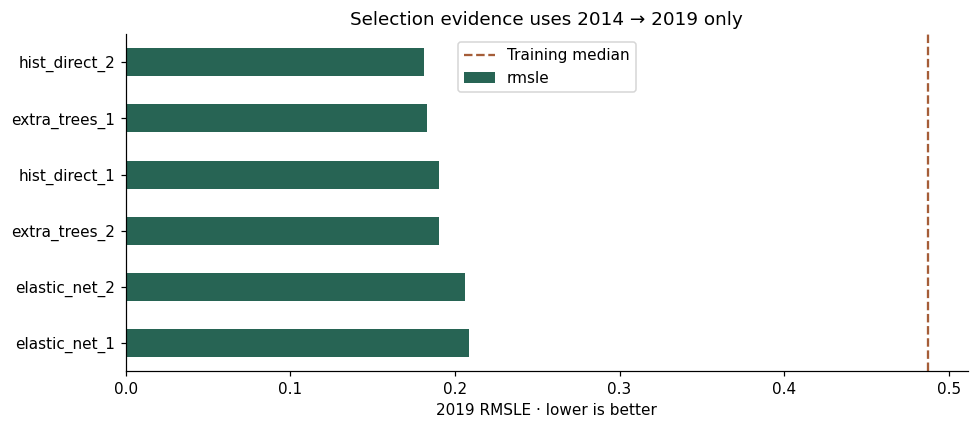

In [5]:
ax = scores.sort_values("rmsle", ascending=False).plot.barh(x="candidate", y="rmsle", legend=False, color="#276454")
ax.axvline(baseline["rmsle"], color="#a55d38", linestyle="--", label="Training median")
ax.set(xlabel="2019 RMSLE · lower is better", ylabel="", title="Selection evidence uses 2014 → 2019 only")
ax.legend(); plt.tight_layout(); plt.show()

**Reading the evidence:** histogram gradient boosting (`hist_direct_2`) is selected
        by validation RMSLE. This decision is not revisited after looking at 2024.
        The search is deliberately small; it is not proof that this is the best possible model.

## 4. Check that each county stays in one geographic fold

        This measures generalization to held-out counties. It is not future forecasting
        and does not hold out entire states or spatial buffers. Neighboring counties can
        remain correlated across folds. The mean below averages fold scores; it is not
        a pooled out-of-fold R².

In [6]:
from sklearn.model_selection import GroupKFold
assignments = read_csv("geographic_fold_assignments.csv")
assert not assignments.county_fips.duplicated().any()
assert assignments.fold.nunique() == 5
assert set(assignments.county_fips) == set(development.county_fips)
folds = list(GroupKFold(n_splits=5).split(development, groups=development.county_fips))
checks = []
for fold, (ti, vi) in enumerate(folds, 1):
    tr, va = development.iloc[ti], development.iloc[vi]
    assert set(tr.county_fips).isdisjoint(va.county_fips)
    assert set(va.county_fips) == set(assignments.loc[assignments.fold.eq(fold), "county_fips"])
    checks.append({"fold": fold, "training_rows": len(tr), "held_out_rows": len(va),
                   "held_out_counties": va.county_fips.nunique(), "overlapping_counties": 0})
display(pd.DataFrame(checks))

,fold,training_rows,held_out_rows,held_out_counties,overlapping_counties
0,1,5024,1257,629,0
1,2,5025,1256,628,0
2,3,5025,1256,628,0
3,4,5025,1256,629,0
4,5,5025,1256,629,0


In [7]:
if RETRAIN:
    geographic_rows = []
    with threadpool_limits(limits=2):
        for fold, (ti, vi) in enumerate(folds, 1):
            tr, va = development.iloc[ti], development.iloc[vi]
            # Tuning sees only training counties, separated into 2014 and 2019.
            _, fold_winners = select_candidates(tr.loc[tr.year.eq(2014)],
                tr.loc[tr.year.eq(2019)], features, candidates)
            for candidate in fold_winners:
                fitted = fit_model(candidate, tr, features)
                geographic_rows.append({"fold": fold, "model": candidate.estimator,
                    "candidate": candidate.name, "rows": len(va),
                    **regression_metrics(va[TARGET], value_prediction(fitted, va, features))})
            geographic_rows.append({"fold": fold, "model": "training_median",
                "candidate": "training_median", "rows": len(va),
                **regression_metrics(va[TARGET], np.full(len(va), tr[TARGET].median()))})
    geographic = pd.DataFrame(geographic_rows)
    saved_geo = read_csv("geographic_metrics.csv")
    np.testing.assert_allclose(geographic.sort_values(["fold", "model"]).rmsle,
                              saved_geo.sort_values(["fold", "model"]).rmsle, rtol=1e-6)
else:
    geographic = read_csv("geographic_metrics.csv")
display(geographic.groupby("model")[["rmsle", "mae_2024_usd", "r2"]].agg(["mean", "std"]).round(4))

rmsle         mae_2024_usd                 r2        
                          mean     std         mean        std    mean     std
model                                                                         
elastic_net             0.1901  0.0040   27087.7354  1113.1061  0.8286  0.0178
extra_trees             0.1807  0.0058   25420.4405  1300.2760  0.8359  0.0285
hist_gradient_boosting  0.1765  0.0052   24607.1207   901.2675  0.8412  0.0187
training_median         0.4658  0.0109   66847.4403  1934.3650 -0.0778  0.0140

## 5. Handoff to final evaluation

        The selected name, candidate parameters and baseline are stored in `selection.json`.
        Every trained pipeline fits its preprocessing using only its own training rows.
        The next notebook evaluates frozen family winners on 2024 and uses those outcomes
        for reporting and diagnosis, never for a second selection round.

        [Continue to evaluation and interpretation →](03_evaluation_and_interpretation.ipynb)